# Session 6: Urban Green Mapping with Machine Learning
**MOOC Series: From Satellite Data to Insights with Digital Earth Sweden**

---

## Session outline

- Recap: rebuilding the cloud-free composite and NDVI product from Session 5
- Turning NDVI into training labels for binary urban green classification
- Preparing pixel-level feature and label arrays for scikit-learn
- Training and evaluating a Random Forest classifier
- Deploying the trained model to a brand-new city: Stockholm

This is the final session of the course. By the end of it you will have trained a machine learning model that maps urban green space directly from Sentinel-2 reflectance — and applied that model, without any retraining, to a city it has never seen. This is the culmination of everything covered in Sessions 1–5: connecting to the backend, loading and visualizing data, computing NDVI, working with datacubes, and building cloud-free composites.

---

## 1. Setup

In [1]:
import io
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import openeo

# Connect to Digital Earth Sweden
connection = openeo.connect('https://openeo.digitalearth.se')
connection.authenticate_basic(username='testuser', password='secretpassword')

# Training area: Karlstad, Sweden (same area used in Session 5)
aoi_karlstad = {
    'west':  13.460930954751282,
    'east':  13.585449709728213,
    'south': 59.36327761288911,
    'north': 59.40107161575003,
    'crs':   'EPSG:4326',
}
timespan_karlstad = ['2026-06-01', '2026-07-01']
max_cloud_cover = 20  # Scene-level pre-filter: drop scenes with > 20% cloud cover

print('Connected to Digital Earth Sweden.')

Connected to Digital Earth Sweden.


## 2. Recap: rebuilding the Session 5 pipeline

In Session 5 we built two analysis-ready products over Karlstad:

- A **cloud-free true-color composite** — the four spectral bands (B02, B03, B04, B08), cloud-masked using the QAI layer and reduced over time with the median.
- A **cloud-free NDVI composite** — NDVI computed per scene, quality-masked, and reduced over time with the mean.

These give us exactly what we need for machine learning:

- The **spectral composite** becomes the **feature matrix** (what the classifier sees).
- The **NDVI composite**, thresholded, becomes the **label matrix** (what the classifier learns to predict).

Rather than repeating the masking code inline, we wrap the Session 5 workflow in a single reusable function. We will call it twice in this session: once for the Karlstad training area, and once for a brand-new area later on.

In [2]:
def create_cloud_mask(qai_band):
    # Bits 1 and 2 are cloud state bits -> shift bits one bit to the right
    shifted = qai_band.process('bitwise_right_shift', x=qai_band, y=1)
    # Isolate the two bits using a bit mask (binary 11 is 3)
    cloud_state = shifted.process('bitwise_and', x=shifted, y=3)
    # Confident, opaque cloud (integer value 2)
    return cloud_state == 2

def extract_bit(band, bit_position):
    shifted = band.process('bitwise_right_shift', x=band, y=bit_position)
    return shifted.process('bitwise_and', x=shifted, y=1)

def create_quality_mask(qai_band):
    subzero_mask = extract_bit(qai_band, 8) == 1
    saturation_mask = extract_bit(qai_band, 9) == 1
    return subzero_mask.process('or', x=subzero_mask, y=saturation_mask)

def build_analysis_ready_datacubes(aoi, timespan, max_cloud_cover=20):
    # Reproduces the Session 5 pipeline: cloud-masked composite + quality-masked NDVI composite
    bands = connection.load_collection(
        collection_id='des_s2_msi_l2a',
        spatial_extent=aoi,
        temporal_extent=timespan,
        bands=['B02', 'B03', 'B04', 'B08'],
        properties={'eo:cloud_cover': lambda x: x <= max_cloud_cover},
    )
    qai = connection.load_collection(
        collection_id='des_s2_msi_l2a',
        spatial_extent=aoi,
        temporal_extent=timespan,
        bands=['QAI'],
        properties={'eo:cloud_cover': lambda x: x <= max_cloud_cover},
    )

    # Cloud mask -> cloud-free spectral composite (median)
    cloud_mask = qai.band('QAI').apply(lambda x: create_cloud_mask(x))
    cloud_mask = cloud_mask.resample_cube_spatial(bands)
    bands_masked = bands.mask(cloud_mask)
    composite = bands_masked.reduce_dimension(dimension='t', reducer='median')

    # Quality mask -> cloud-free NDVI composite (mean)
    ndvi = bands_masked.ndvi(nir='B08', red='B04')
    quality_mask = qai.band('QAI').apply(lambda x: create_quality_mask(x))
    quality_mask = quality_mask.resample_cube_spatial(ndvi)
    ndvi = ndvi.mask(quality_mask)
    ndvi_composite = ndvi.reduce_dimension(dimension='t', reducer='mean')

    return composite, ndvi_composite

## 3. Cloud-free composite over Karlstad (training area)

We call the function above to reproduce the exact composite and NDVI product from Session 5.

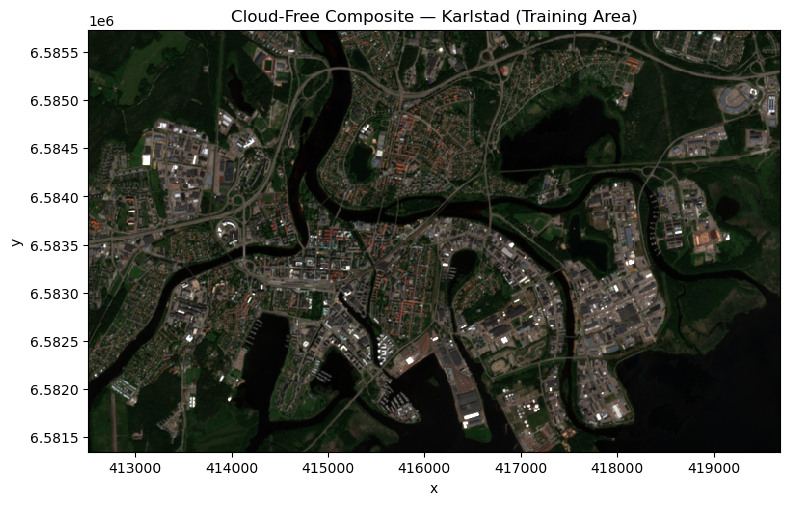

In [3]:
composite, ndvi_composite = build_analysis_ready_datacubes(
    aoi_karlstad, timespan_karlstad, max_cloud_cover
)

# Visualize the true-color composite
composite_tif = composite.download(format='GTiff')
da = xr.open_dataarray(io.BytesIO(composite_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
rgb = da.sel(band=['B04', 'B03', 'B02'])

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb.plot.imshow(rgb='band', vmin=0, vmax=4_000, ax=ax)
ax.set_aspect('equal')
ax.set_title('Cloud-Free Composite — Karlstad (Training Area)')
plt.tight_layout()
plt.show()

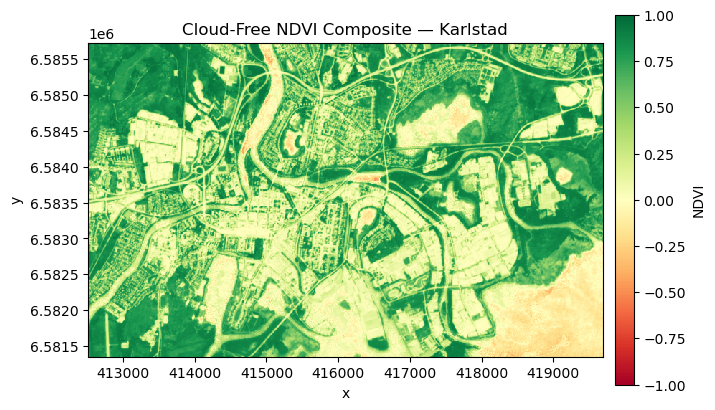

In [4]:
ndvi_tif = ndvi_composite.download(format='GTiff')
ndvi_da = xr.open_dataarray(io.BytesIO(ndvi_tif), engine='rasterio')
ndvi_da = ndvi_da.squeeze()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
cbar_kwargs = {'shrink': 0.6, 'aspect': 20, 'pad': 0.02, 'label': 'NDVI'}
ndvi_da.plot.imshow(ax=ax, cmap='RdYlGn', cbar_kwargs=cbar_kwargs, vmin=-1, vmax=1)
ax.set_aspect('equal')
ax.set_title('Cloud-Free NDVI Composite — Karlstad')
plt.show()

## 4. From NDVI to training labels

**Urban green space** covers a wide spectrum of vegetated surfaces — parks, gardens, tree-lined streets, urban forests — anything with a live plant canopy, as opposed to paved, built, or bare surfaces. NDVI is a reliable, physically grounded proxy for exactly this distinction, so we use it to generate training labels automatically, without any manual annotation:

- `NDVI > 0.3` → **urban green** (1)
- `NDVI ≤ 0.3` → **non-green** (0)

This threshold is slightly higher than the general vegetation threshold used earlier in the course (0.2), because we want the classifier to focus on well-vegetated green space rather than sparse or stressed vegetation. In a production system you would replace or refine these labels with field-collected ground truth.

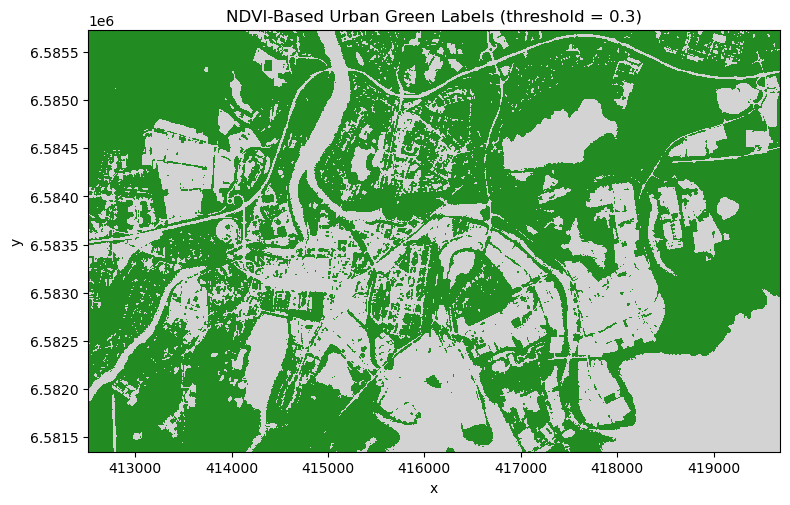

In [5]:
ndvi_threshold = 0.3
urban_green_mask = ndvi_composite > ndvi_threshold

# Visualize the label mask
mask_tif = urban_green_mask.download(format='GTiff')
mask_da = xr.open_dataarray(io.BytesIO(mask_tif), engine='rasterio').squeeze()

cmap = ListedColormap(['lightgrey', 'forestgreen'])
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
mask_da.plot.imshow(ax=ax, cmap=cmap, add_colorbar=False)
ax.set_aspect('equal')
ax.set_title(f'NDVI-Based Urban Green Labels (threshold = {ndvi_threshold})')
plt.tight_layout()
plt.show()

## 5. Preparing feature and label arrays for scikit-learn

scikit-learn expects a 2-D feature matrix `(n_samples, n_features)` and a 1-D label vector `(n_samples,)`. Our data currently lives on a 2-D spatial grid, so we flatten every pixel into one row.

We reuse the GTiff bytes already downloaded for visualization above rather than re-downloading as NetCDF. NetCDF export of a thresholded (boolean) cube currently trips a backend serialization bug (an internal `numpy.datetime64` timestamp attribute that xarray's NetCDF writer rejects) — GTiff avoids the problem entirely and saves a redundant download.

In [6]:
# Reuse the GTiff bytes already downloaded for visualization (band order: B02, B03, B04, B08)
composite_da = xr.open_dataarray(io.BytesIO(composite_tif), engine='rasterio')
composite_da = composite_da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])

# Reuse the GTiff bytes already downloaded for the label mask visualization
labels_da = xr.open_dataarray(io.BytesIO(mask_tif), engine='rasterio').squeeze()

print('Feature cube shape:', composite_da.shape)
print('Label  cube shape :', labels_da.shape)

Feature cube shape: (4, 438, 718)
Label  cube shape : (438, 718)


We flatten the spatial dimensions so that every pixel becomes a row in the feature matrix. The four spectral bands become four columns.

In [7]:
bands_np = composite_da.values  # shape: (4, H, W)
mask_np = labels_da.values      # shape: (H, W)

H, W = mask_np.shape

# (4, H, W) -> (H*W, 4): each row is a pixel, each column is a spectral band
X = bands_np.reshape(4, -1).T
# (H, W) -> (H*W,)
y = mask_np.flatten()

We split 80% of pixels into a training set and hold back 20% for evaluation. `stratify=y` preserves the green / non-green class balance in both splits.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training pixels: {len(X_train):,}  |  Test pixels: {len(X_test):,}')

Training pixels: 251,587  |  Test pixels: 62,897


## 6. Training the Random Forest classifier

A **Random Forest** is an ensemble of decision trees, each trained on a random subset of pixels and features. Averaging their votes produces a model that is robust to noise and resistant to overfitting — a good default choice for pixel-based land cover classification.

We train a forest of 100 trees using the four spectral bands as input features.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,          # Number of trees in the ensemble
    max_depth=10,               # Maximum depth of each tree
    class_weight='balanced',    # Correct for class imbalance
    n_jobs=-1,                  # Parallelize training across all CPU cores
    random_state=42,            # Seed for reproducibility
)
rf.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 7. Model evaluation

We evaluate the trained model on the held-out 20% test set:

- **Classification report** — per-class precision, recall, and F1-score.
- **Confusion matrix** — counts of correct and incorrect predictions per class.

Because the labels themselves come from an NDVI threshold, high accuracy here mainly tells us that the Random Forest has learned to reproduce the NDVI decision boundary directly from raw reflectance — without ever computing NDVI itself.

              precision    recall  f1-score   support

   Non-green       0.98      0.99      0.98     24598
 Urban green       0.99      0.98      0.99     38299

    accuracy                           0.99     62897
   macro avg       0.98      0.99      0.99     62897
weighted avg       0.99      0.99      0.99     62897



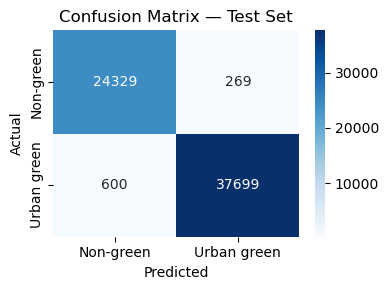

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Non-green', 'Urban green']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-green', 'Urban green'],
    yticklabels=['Non-green', 'Urban green'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 8. Deploying the classifier to a new area: Stockholm

The real test of a machine learning model is whether it **generalizes** — whether it has learned meaningful, transferable relationships between spectral reflectance and land cover, rather than memorizing the training scene.

We now apply the trained classifier, completely unchanged, to **Södermalm**, a dense urban island in central Stockholm. This is a very different environment from semi-rural Karlstad: narrow streets, dense building blocks, and pocket parks rather than open forest and farmland. If the model has learned general spectral patterns, it should still correctly identify parks, courtyards, and tree-lined streets as urban green.

We reuse the exact same pipeline — `build_analysis_ready_datacubes` — so the new composite is processed identically to the training data.

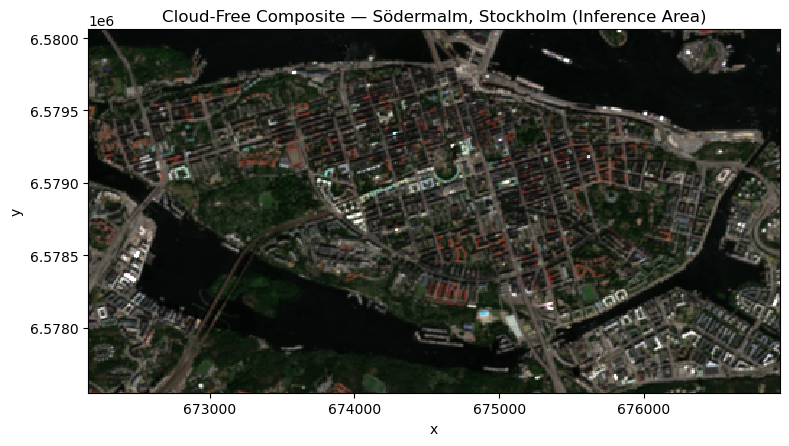

In [11]:
aoi_stockholm = {
    'west':  18.025636,
    'east':  18.107674,
    'south': 59.301681,
    'north': 59.322233,
    'crs':   'EPSG:4326',
}
timespan_stockholm = ['2026-06-01', '2026-07-01']

composite_stockholm, _ = build_analysis_ready_datacubes(
    aoi_stockholm, timespan_stockholm, max_cloud_cover
)

# Visualize the true-color composite over the new area
composite_stockholm_tif = composite_stockholm.download(format='GTiff')
da = xr.open_dataarray(io.BytesIO(composite_stockholm_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
rgb = da.sel(band=['B04', 'B03', 'B02'])

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb.plot.imshow(rgb='band', vmin=0, vmax=4_000, ax=ax)
ax.set_aspect('equal')
ax.set_title('Cloud-Free Composite — Södermalm, Stockholm (Inference Area)')
plt.tight_layout()
plt.show()

## 9. Running inference and interpreting the result

We apply the same reshape pipeline used during training, then call `rf.predict()` — no retraining needed. The prediction is reshaped back to the original image dimensions and displayed next to the true-color image for comparison.

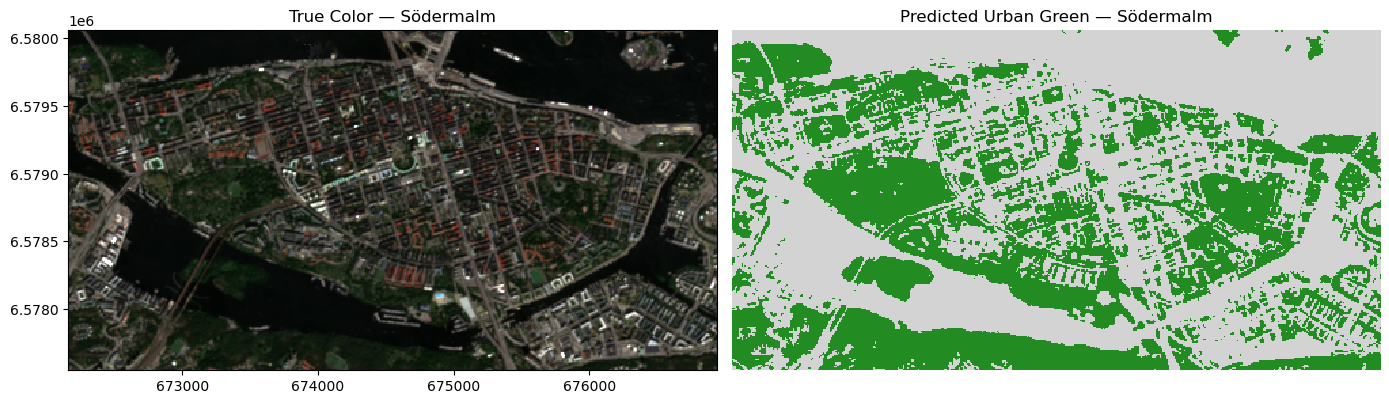

In [12]:
# Reuse the GTiff bytes already downloaded for the Stockholm true-color preview
X_stockholm_bands = xr.open_dataarray(
    io.BytesIO(composite_stockholm_tif), engine='rasterio'
).values  # shape: (4, H, W)
H_new, W_new = X_stockholm_bands.shape[1], X_stockholm_bands.shape[2]
X_stockholm = X_stockholm_bands.reshape(4, -1).T

# Predict with the already-trained Random Forest — no re-training needed
y_pred_stockholm = rf.predict(X_stockholm).reshape(H_new, W_new)

# Visualize true color and predicted urban green map side by side
cmap = ListedColormap(['lightgrey', 'forestgreen'])
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

rgb.plot.imshow(rgb='band', vmin=0, vmax=4_000, ax=axes[0], add_labels=False)
axes[0].set_title('True Color — Södermalm')
axes[0].set_aspect('equal')

axes[1].imshow(y_pred_stockholm, cmap=cmap, interpolation='none')
axes[1].set_title('Predicted Urban Green — Södermalm')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Compare the two panels: the parks, courtyards, and tree-lined streets visible in the true-color image are picked out in green in the prediction, even though the model has never seen a single pixel from Stockholm during training. This is the core value of the approach — a classifier trained once on a small, well-understood area can be deployed at scale across new cities, without collecting new ground-truth labels for every location.

---

## Summary

In this final session you:

- Reused the Session 5 cloud-masking pipeline to build analysis-ready feature and label products.
- Generated training labels automatically by thresholding a cloud-free NDVI composite.
- Reshaped spatial datacubes into pixel-level feature and label arrays for scikit-learn.
- Trained and evaluated a Random Forest classifier for binary urban green classification.
- Deployed the trained classifier to Södermalm, Stockholm — an area it had never seen — and visually verified that it generalizes.

This completes the course. Starting from a single satellite image in Session 1, you have progressively built the skills to load, visualize, analyze, composite, and now automatically classify Earth observation data — the full journey from satellite data to insight.

---
*Digital Earth Sweden MOOC — Session 6 of 6*